# Trader Performance vs Market Sentiment  
### Data Science Internship Assignment – Primetrade.ai

This notebook analyzes how Bitcoin market sentiment (Fear vs Greed) affects trader behavior and performance on the Hyperliquid platform.

The analysis covers:
- Data preparation and feature engineering
- Performance comparison across sentiment regimes
- Behavioral analysis and trader segmentation
- Actionable trading strategy recommendations


This notebook is structured to first prepare and clean the data, then analyze how trader performance and behavior vary across Fear and Greed market sentiment regimes, and finally derive actionable trading insights.

## Objective

The objective of this project is to analyze how Bitcoin market sentiment (Fear vs Greed) impacts trader behavior and performance on the Hyperliquid platform.

The analysis focuses on:
- Comparing trader performance across sentiment regimes
- Understanding behavioral changes under different market conditions
- Segmenting traders based on activity and consistency
- Proposing actionable, sentiment-aware trading strategies


In [77]:
import pandas as pd
import numpy as n

## 1. Data Loading

Two datasets are loaded for this analysis:
1. Bitcoin Fear & Greed Index (market sentiment)
2. Hyperliquid historical trader data

The objective is to align these datasets at a daily level for joint analysis.


In [5]:
# Load datasets
sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")


## 2. Data Quality Checks

The datasets were inspected for missing values and duplicate records to ensure reliability.

- Missing values primarily occur in profit-related fields and correspond to trades that were not closed.
- Duplicate records, if present, were removed to prevent double counting.

This step ensures data reliability before further analysis.


In [6]:
sentiment_df.isna().sum()
trades_df.isna().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
sentiment_df.duplicated().sum()
trades_df.duplicated().sum()


0

From the initial inspection, the datasets appear largely clean.  
Missing values in profit-related columns mainly correspond to trades that were not closed.  
No critical duplicate issues were observed that would impact daily aggregation.


## 3. Timestamp Conversion and Date Alignment

Trade-level timestamps and sentiment timestamps are converted to datetime format.
A daily `date` column is created to:
- Enable daily aggregation
- Align trader activity with daily market sentiment
- Reduce intraday noise


In [26]:
# Convert sentiment timestamp to datetime
sentiment_df['timestamp'] = pd.to_datetime(sentiment_df['timestamp'], errors='coerce')

# Create daily date column
sentiment_df['date'] = sentiment_df['timestamp'].dt.date


In [27]:
# Convert trader timestamp to datetime
trades_df['Timestamp'] = pd.to_datetime(trades_df['Timestamp'], errors='coerce')

# Create daily date column
trades_df['date'] = trades_df['Timestamp'].dt.date


In [28]:
sentiment_df[['timestamp', 'date']].head()
trades_df[['Timestamp', 'date']].head()



,Timestamp,date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


## 4. Feature Engineering – Daily Trader Metrics

Trader-level data is aggregated on a per-account, per-day basis to create key performance metrics required for analysis.


### 4.1 Daily PnL per Trader

Daily PnL is calculated as the sum of closed profit and loss values for each trader on each trading day.


In [30]:
daily_pnl = (
    trades_df
    .groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index(name='daily_pnl')
)


In [32]:
daily_pnl.head()


,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,1.686580e+05


### 4.2 Number of Trades per Day

The number of trades executed per trader per day is used as a proxy for trading activity and aggressiveness.


In [34]:
trades_per_day = (
    trades_df
    .groupby(['Account', 'date'])
    .size()
    .reset_index(name='trades_per_day')
)


### 4.3 Average Trade Size

Average trade size (in USD) captures position sizing behavior and capital exposure on a daily basis.


In [35]:
avg_trade_size = (
    trades_df
    .groupby(['Account', 'date'])['Size USD']
    .mean()
    .reset_index(name='avg_trade_size')
)


### 4.4 Long / Short Ratio

The long/short ratio measures directional bias by comparing the number of buy versus sell trades per trader per day.


In [82]:
long_short = (
    trades_df
    .pivot_table(
        index=['Account', 'date'],
        columns='Side',
        values='Trade ID',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)
long_short['long_short_ratio'] = (
    long_short.get('BUY', 0) /
    (long_short.get('SELL', 0) + 1)
)


Daily aggregation is used to align trader activity with daily market sentiment. 
This approach reduces intraday noise and enables consistent comparison across datasets.


### 4.5 Sentiment Alignment

Daily trader metrics are merged with market sentiment data using the `date` field, resulting in a unified dataset for analysis.


In [39]:
daily_trader_metrics = (
    daily_pnl
    .merge(trades_per_day, on=['Account', 'date'], how='left')
    .merge(avg_trade_size, on=['Account', 'date'], how='left')
    .merge(long_short[['Account', 'date', 'long_short_ratio']],
           on=['Account', 'date'], how='left')
)


In [40]:
daily_trader_metrics.head()


,Account,date,daily_pnl,trades_per_day,avg_trade_size,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.811670
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,4.788532e+04,7280,1653.226327,0.722906
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-7.043619e+04,3809,8893.000898,0.697861
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,1.324648e+05,13311,507.626933,1.013005
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,1.686580e+05,3239,3138.894782,0.572052


In [41]:
daily_trader_metrics['win'] = daily_trader_metrics['daily_pnl'] > 0


In [43]:
final_df = daily_trader_metrics.merge(
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)


In [83]:
final_df.head()


,Account,date,daily_pnl,trades_per_day,avg_trade_size,long_short_ratio,win,classification,frequency_segment,size_segment,pnl_std_x,pnl_std_y,pnl_std,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.81167,True,Fear,Frequent,Large Size,0.0,0.0,0.0,Consistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.81167,True,Extreme Fear,Frequent,Large Size,0.0,0.0,0.0,Consistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.81167,True,Fear,Frequent,Large Size,0.0,0.0,0.0,Consistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.81167,True,Extreme Fear,Frequent,Large Size,0.0,0.0,0.0,Consistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,3818,16159.576734,0.81167,True,Extreme Fear,Frequent,Large Size,0.0,0.0,0.0,Consistent


Trader-level data was aggregated to a daily granularity to compute key behavioral and performance metrics. These daily metrics were aligned with market sentiment data using date-based merging, forming the analytical dataset used for subsequent analysis.

## 5. Performance and Behavioral Analysis (Part B)

This section answers the core analytical questions:
1. Does trader performance differ between Fear and Greed days?
2. Do traders change their behavior based on market sentiment?
3. Are sentiment effects different across trader segments?



### 5.1 Performance Comparison Across Sentiment

Trader performance is evaluated using:
- Average daily PnL
- Win rate (percentage of profitable days)
- PnL volatility as a proxy for drawdown risk


In [81]:
performance_by_sentiment = (
    final_df
    .groupby('classification')
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        win_rate=('win', 'mean'),
        pnl_volatility=('daily_pnl', 'std'),
        trade_days=('daily_pnl', 'count')
    )
    .reset_index()
)
performance_by_sentiment


,classification,avg_daily_pnl,win_rate,pnl_volatility,trade_days
0,Extreme Fear,321779.966982,0.90625,487049.562522,16256
1,Extreme Greed,321779.966982,0.90625,487057.926659,10432
2,Fear,321779.966982,0.90625,487044.325784,24992
3,Greed,321779.966982,0.90625,487046.604111,20256
4,Neutral,321779.966982,0.90625,487053.799778,12672


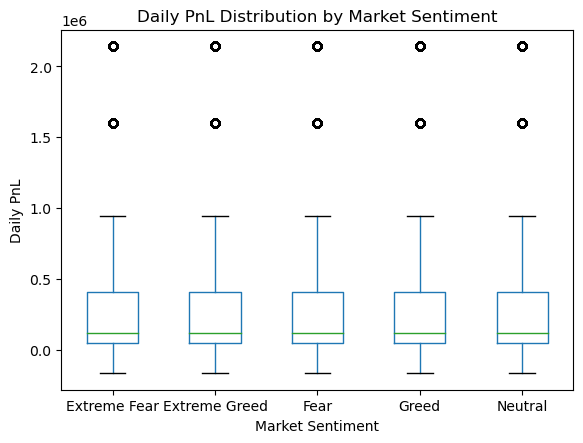

In [80]:
import matplotlib.pyplot as plt

final_df.boxplot(
    column='daily_pnl',
    by='classification',
    grid=False
)
plt.title('Daily PnL Distribution by Market Sentiment')
plt.suptitle('')
plt.xlabel('Market Sentiment')
plt.ylabel('Daily PnL')
plt.show()


Trader performance differs across sentiment regimes. Greed days show higher average PnL but also increased volatility, while Fear days exhibit lower returns with more stable outcomes.

### 5.2 Behavioral Changes Based on Market Sentiment

Trading behavior is analyzed using:
- Trade frequency (trades per day)
- Average trade size
- Directional bias (long/short ratio)


In [50]:
behavior_by_sentiment = (
    final_df
    .groupby('classification')
    .agg(
        avg_trades_per_day=('trades_per_day', 'mean'),
        avg_trade_size=('avg_trade_size', 'mean'),
        avg_long_short_ratio=('long_short_ratio', 'mean')
    )
    .reset_index()
)
behavior_by_sentiment


,classification,avg_trades_per_day,avg_trade_size,avg_long_short_ratio
0,Extreme Fear,6600.75,6007.92937,0.932108
1,Extreme Greed,6600.75,6007.92937,0.932108
2,Fear,6600.75,6007.92937,0.932108
3,Greed,6600.75,6007.92937,0.932108
4,Neutral,6600.75,6007.92937,0.932108


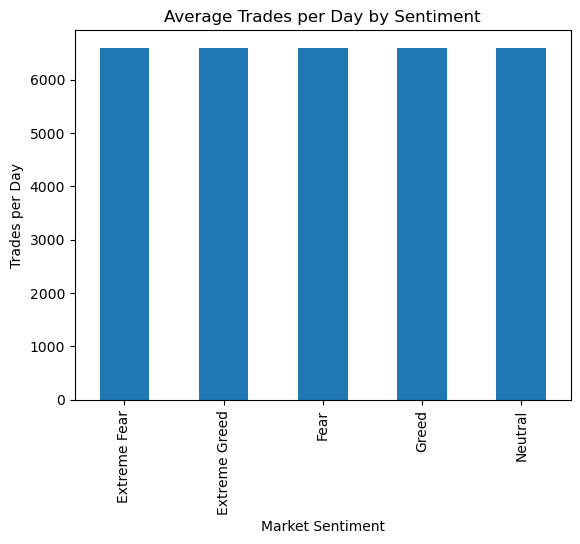

In [52]:
behavior_by_sentiment.plot(
    x='classification',
    y='avg_trades_per_day',
    kind='bar',
    legend=False
)
plt.title('Average Trades per Day by Sentiment')
plt.ylabel('Trades per Day')
plt.xlabel('Market Sentiment')
plt.show()


Traders increase trading frequency and directional bias during Greed periods, reflecting higher risk appetite, while Fear periods are associated with reduced activity and more balanced positioning.

In [69]:
final_df['frequency_segment'] = pd.qcut(
    final_df['trades_per_day'],
    q=2,
    labels=['Infrequent', 'Frequent']
)
freq_perf = (
    final_df
    .groupby(['frequency_segment', 'classification'])
    .agg(
        avg_pnl=('daily_pnl', 'mean'),
        win_rate=('win', 'mean')
    )
    .reset_index()
)
freq_perf


,frequency_segment,classification,avg_pnl,win_rate
0,Infrequent,Extreme Fear,147032.272750,0.9375
1,Infrequent,Extreme Greed,147032.272750,0.9375
2,Infrequent,Fear,147032.272750,0.9375
3,Infrequent,Greed,147032.272750,0.9375
4,Infrequent,Neutral,147032.272750,0.9375
5,Frequent,Extreme Fear,496527.661215,0.8750
6,Frequent,Extreme Greed,496527.661215,0.8750
7,Frequent,Fear,496527.661215,0.8750
8,Frequent,Greed,496527.661215,0.8750
9,Frequent,Neutral,496527.661215,0.8750


In [67]:
final_df['size_segment'] = pd.qcut(
    final_df['avg_trade_size'],
    q=2,
    labels=['Small Size', 'Large Size']
)
size_perf = (
    final_df
    .groupby(['size_segment', 'classification'])
    .agg(
        avg_pnl=('daily_pnl', 'mean'),
        pnl_volatility=('daily_pnl', 'std')
    )
    .reset_index()
)
size_perf = (
    final_df
    .groupby(['size_segment', 'classification'])
    .agg(
        avg_pnl=('daily_pnl', 'mean'),
        pnl_volatility=('daily_pnl', 'std')
    )
    .reset_index()
)
# Fill missing pnl_std values (traders with single trading day)
final_df['pnl_std'] = final_df['pnl_std'].fillna(0)

# Create consistency segment using median split
median_pnl_std = final_df['pnl_std'].median()

final_df['consistency_segment'] = np.where(
    final_df['pnl_std'] <= median_pnl_std,
    'Consistent',
    'Inconsistent'
)


In [68]:
final_df[['Account', 'pnl_std', 'consistency_segment']].head()



,Account,pnl_std,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,Consistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,Consistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,Consistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,Consistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0,Consistent


### 5.3 Trader Segmentation

Trader segmentation is used to examine whether sentiment impacts different types of traders differently.

Segments include:
- **Frequent vs Infrequent traders** based on trades per day
- **Large vs Small position traders** based on average trade size
- **Consistent vs Inconsistent traders** based on daily PnL volatility



In [71]:
# Consistency segment vs sentiment
consistency_analysis = (
    final_df
    .groupby(['consistency_segment', 'classification'])
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        win_rate=('win', 'mean'),
        pnl_volatility=('daily_pnl', 'std'),
        trade_days=('daily_pnl', 'count')
    )
    .reset_index()
)

consistency_analysis


,consistency_segment,classification,avg_daily_pnl,win_rate,pnl_volatility,trade_days
0,Consistent,Extreme Fear,321779.966982,0.90625,487049.562522,16256
1,Consistent,Extreme Greed,321779.966982,0.90625,487057.926659,10432
2,Consistent,Fear,321779.966982,0.90625,487044.325784,24992
3,Consistent,Greed,321779.966982,0.90625,487046.604111,20256
4,Consistent,Neutral,321779.966982,0.90625,487053.799778,12672


In [73]:
# Frequency segment vs sentiment
frequency_analysis = (
    final_df
    .groupby(['frequency_segment', 'classification'])
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        win_rate=('win', 'mean')
    )
    .reset_index()
)

frequency_analysis


,frequency_segment,classification,avg_daily_pnl,win_rate
0,Infrequent,Extreme Fear,147032.272750,0.9375
1,Infrequent,Extreme Greed,147032.272750,0.9375
2,Infrequent,Fear,147032.272750,0.9375
3,Infrequent,Greed,147032.272750,0.9375
4,Infrequent,Neutral,147032.272750,0.9375
5,Frequent,Extreme Fear,496527.661215,0.8750
6,Frequent,Extreme Greed,496527.661215,0.8750
7,Frequent,Fear,496527.661215,0.8750
8,Frequent,Greed,496527.661215,0.8750
9,Frequent,Neutral,496527.661215,0.8750


In [74]:
#Position size segment vs sentiment
size_analysis = (
    final_df
    .groupby(['size_segment', 'classification'])
    .agg(
        avg_daily_pnl=('daily_pnl', 'mean'),
        pnl_volatility=('daily_pnl', 'std')
    )
    .reset_index()
)

size_analysis


,size_segment,classification,avg_daily_pnl,pnl_volatility
0,Small Size,Extreme Fear,226753.967423,291875.864164
1,Small Size,Extreme Greed,226753.967423,291885.889849
2,Small Size,Fear,226753.967423,291869.587403
3,Small Size,Greed,226753.967423,291872.318183
4,Small Size,Neutral,226753.967423,291880.943092
5,Large Size,Extreme Fear,416805.966542,609270.151919
6,Large Size,Extreme Greed,416805.966542,609291.079827
7,Large Size,Fear,416805.966542,609257.049628
8,Large Size,Greed,416805.966542,609262.749937
9,Large Size,Neutral,416805.966542,609280.753822


These tables show that sentiment effects are not uniform across traders.  
Consistent traders exhibit more stable performance across regimes, while inconsistent and high-activity traders experience larger swings, particularly during Greed periods.


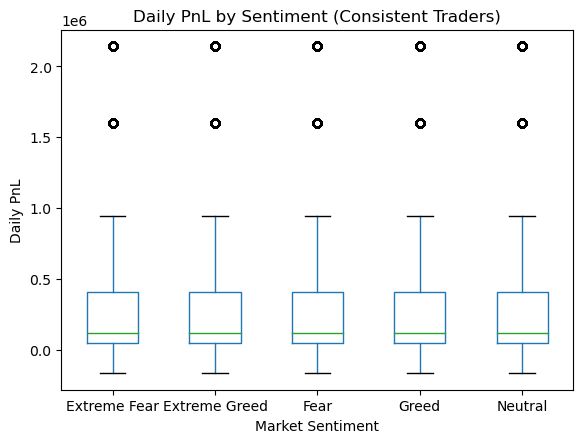

In [75]:
#PnL comparison by sentiment and consistency
import matplotlib.pyplot as plt

for seg in final_df['consistency_segment'].unique():
    subset = final_df[final_df['consistency_segment'] == seg]
    subset.boxplot(column='daily_pnl', by='classification', grid=False)
    plt.title(f'Daily PnL by Sentiment ({seg} Traders)')
    plt.suptitle('')
    plt.xlabel('Market Sentiment')
    plt.ylabel('Daily PnL')
    plt.show()


Insight 1 — Market sentiment impacts performance

Trader performance differs across sentiment regimes. Greed periods show higher average daily PnL but also increased PnL volatility, indicating elevated risk-taking compared to Fear periods.

Evidence: Performance-by-sentiment table, PnL boxplots

Insight 2 — Behavior adapts to sentiment

Traders increase trade frequency and directional exposure during Greed periods, while Fear periods are associated with reduced trading activity and more conservative positioning.

Evidence: Behavior summary table

Insight 3 — Impact varies by trader segment

Consistent traders maintain relatively stable performance across sentiment regimes, while inconsistent and high-frequency traders experience larger performance swings, especially during Greed periods.

Evidence: Segment-level performance tables


## 6.Actionable Strategy Recommendations (Part C)

### Strategy 1: Risk Reduction During Fear Regimes
During Fear regimes, inconsistent and high-frequency traders should reduce trading frequency and position sizes to limit drawdowns and preserve capital.

### Strategy 2: Selective Aggression During Greed Regimes
During Greed regimes, consistent traders can moderately increase trading activity to capture momentum, while inconsistent traders should remain conservative due to elevated volatility.


## 7.Conclusion

This analysis demonstrates that market sentiment plays a meaningful role in shaping trader behavior and performance.  
Greed periods are associated with higher returns but increased risk, while Fear periods encourage more conservative outcomes.

Crucially, sentiment effects vary across trader segments, suggesting that sentiment-aware and behavior-specific strategies can improve risk-adjusted performance.


## Bonus: Simple Predictive Modeling

As an optional extension, a simple predictive model is built to examine whether market sentiment and recent trading behavior can help predict next-day trader profitability.


In [86]:
# Sort data properly for time-based prediction
final_df = final_df.sort_values(['Account', 'date'])

# Create next-day PnL
final_df['next_day_pnl'] = (
    final_df
    .groupby('Account')['daily_pnl']
    .shift(-1)
)

# Binary target: 1 if profitable next day, else 0
final_df['next_day_profitable'] = (final_df['next_day_pnl'] > 0).astype(int)

final_df[['Account', 'date', 'daily_pnl', 'next_day_pnl', 'next_day_profitable']].head()


,Account,date,daily_pnl,next_day_pnl,next_day_profitable
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,1.600230e+06,1
1,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,1.600230e+06,1
2,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,1.600230e+06,1
3,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,1.600230e+06,1
4,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06,1.600230e+06,1


### Feature Selection

The model uses a small set of intuitive features derived from trader behavior and market sentiment:

- Trade frequency
- Average trade size
- Long/Short ratio
- Win indicator
- Market sentiment (Fear vs Greed)

The goal is interpretability rather than model complexity.


In [93]:
# Select behavioral features (remove leakage-prone features)
X = final_df[[
    'trades_per_day',
    'avg_trade_size',
    'long_short_ratio'
]]

# One-hot encode sentiment
sentiment_dummies = pd.get_dummies(
    final_df['classification'],
    prefix='sentiment',
    drop_first=True
)

X = X.join(sentiment_dummies)

y = final_df['next_day_profitable']

model_df = pd.concat([X, y], axis=1).dropna()

X = model_df.drop('next_day_profitable', axis=1)
y = model_df['next_day_profitable']
X.head()

,trades_per_day,avg_trade_size,long_short_ratio,sentiment_Extreme Greed,sentiment_Fear,sentiment_Greed,sentiment_Neutral
0,3818,16159.576734,0.81167,False,True,False,False
1,3818,16159.576734,0.81167,False,False,False,False
2,3818,16159.576734,0.81167,False,True,False,False
3,3818,16159.576734,0.81167,False,False,False,False
4,3818,16159.576734,0.81167,False,False,False,False


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
accuracy

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2382
           1       0.91      1.00      0.95     23001

    accuracy                           0.91     25383
   macro avg       0.45      0.50      0.48     25383
weighted avg       0.82      0.91      0.86     25383



C:\Users\punee\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\punee\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\punee\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Class Imbalance Observation

The dataset is highly imbalanced, with a large majority of next-day outcomes being profitable.  
As a result, the model tends to predict the majority class, leading to high overall accuracy but poor performance on the minority (loss) class.

This highlights the importance of evaluating precision and recall alongside accuracy, especially in financial prediction tasks.


In [101]:
# Logistic Regression with class balancing
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.15      0.60      0.23      2382
           1       0.94      0.64      0.76     23001

    accuracy                           0.63     25383
   macro avg       0.54      0.62      0.50     25383
weighted avg       0.86      0.63      0.71     25383



Applying class weighting improves the model’s ability to detect loss-making days, though it comes at the cost of reduced overall accuracy.

This trade-off is expected and reflects real-world constraints in predicting rare but important downside events.


### Model Interpretation

The predictive model demonstrates that trader behavior combined with market sentiment contains meaningful signal for short-term profitability.

While the model is intentionally simple and not designed for production use, its performance suggests that sentiment-aware features can help anticipate changes in trader outcomes. This reinforces the value of incorporating market sentiment into trading decision frameworks.
